# Predicting subsurface eddy tilt from surface signatures

This notebook tests whether surface properties contain predictive information about subsurface eddy tilt. It is a feasibility and generalisation experiment, not an attempt to fill unknown observations.

The primary safeguards are:

- predict eastward and northward tilt components rather than regressing directly on a circular bearing;
- keep all observations from an eddy in the same data partition;
- compare nonlinear and linear models with a mean-vector baseline;
- evaluate displacement-vector, distance, and circular-direction errors separately;
- calculate feature importance only on eddies excluded from fitting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seacofs_tilt_tools as tilt
import ml_subsurface_tools as ml

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42

## 1. Load the surface and tilt data

`add_pv_gradient_terms(..., core_mean=True)` calculates the shallow-water PV-gradient vector using core-mean bathymetry and bathymetric gradients. The workflow uses its magnitude (`PV_grad_mag`) and converts its compass bearing (`PV_grad_theta`) into eastward and northward vector components. This preserves both the magnitude–magnitude and direction–direction relationships with tilt.

In [2]:
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, df_tilt = tilt.load_tilt_tables(paths)

df_eddies = tilt.add_pv_gradient_terms(df_eddies, grid, core_mean=True)

print(f"Rows: {len(df_eddies):,}")
print(f"Unique eddies: {df_eddies['Eddy'].nunique():,}")

df_eddies["PV_grad_east"] = df_eddies["PV_grad_x"]
df_eddies["PV_grad_north"] = df_eddies["PV_grad_y"]
df_eddies[ml.FEATURES + ["TiltDis", "TiltDir"]].head()

Rows: 127,426
Unique eddies: 2,982


,lat,w,Omega,Rc,AR,Age,PV_grad_mag,PV_grad_east,PV_grad_north,Cyc,TiltDis,TiltDir
0,-38.866383,-0.000032,-0.000013,29.449052,1.973172,26,NaN,NaN,NaN,CE,NaN,NaN
1,-38.814279,-0.000041,-0.000017,29.449052,1.859668,26,NaN,NaN,NaN,CE,NaN,NaN
2,-38.816261,-0.000035,-0.000015,32.090160,1.745185,26,NaN,NaN,NaN,CE,NaN,NaN
3,-38.902070,-0.000020,-0.000009,34.827275,1.433213,26,8.269894e-15,-3.022524e-15,-7.697760e-15,CE,19.823350,87.507772
4,-38.935135,-0.000026,-0.000013,37.564389,1.140614,26,1.195343e-14,-8.609373e-16,-1.192239e-14,CE,15.055658,105.302388


### Target-definition checkpoint

Before interpreting model skill, confirm that `TiltDis` and `TiltDir` describe tilt over the same vertical interval for every eddy-day. If the terminal depth varies, absolute distance also represents vertical-profile length. In that case, repeat the analysis with tilt to a fixed depth or with tilt distance divided by vertical separation.

In [ ]:
d_vert = tilt.load_vertical_dictionary(paths)

## 2. Audit target availability and prepare the modelling table

Missing tilt values may not be random. Coverage is reported overall and by polarity before complete cases are selected. Conclusions from the model apply to eddy-days for which a valid tilt was calculated.

In [3]:
coverage = ml.target_availability_summary(df_eddies)
coverage

,rows,valid_tilt_rows,valid_fraction,eddies,eddies_with_tilt
group,,,,,
All,127426,105621,0.828881,2982,2953
AE,64952,53607,0.825333,1446,1422
CE,62474,52014,0.832570,1536,1531


In [4]:
model_df = ml.prepare_modelling_table(df_eddies)

print(f"Complete modelling rows: {len(model_df):,}")
print(f"Independent eddy groups: {model_df['Eddy'].nunique():,}")
print(f"Retained fraction: {len(model_df) / len(df_eddies):.1%}")
model_df[ml.FEATURES + ["TiltDis", "TiltDir", "TiltEast", "TiltNorth"]].describe(include="all").T

Complete modelling rows: 105,621
Independent eddy groups: 2,953
Retained fraction: 82.9%


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
lat,105621.0,NaN,NaN,NaN,-34.003766,3.737487,-40.897018,-37.234974,-34.6313,-30.693728,-25.970556
w,105621.0,NaN,NaN,NaN,0.0,0.000028,-0.000154,-0.00002,0.000006,0.000022,0.000102
Omega,105621.0,NaN,NaN,NaN,0.0,0.000013,-0.00005,-0.000009,0.000003,0.00001,0.000049
Rc,105621.0,NaN,NaN,NaN,80.869862,34.227135,15.883583,55.487275,74.886242,100.453387,284.541529
AR,105621.0,NaN,NaN,NaN,1.549116,0.385641,1.000201,1.265365,1.462219,1.737817,4.603167
Age,105621.0,NaN,NaN,NaN,67.049611,58.390628,22.0,32.0,48.0,80.0,462.0
PV_grad_mag,105621.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PV_grad_east,105621.0,NaN,NaN,NaN,-0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0
PV_grad_north,105621.0,NaN,NaN,NaN,0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0
Cyc,105621,2,AE,53607,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Both `TiltDir` and `PV_grad_theta` are compass bearings (0° north, 90° east). The tilt targets are therefore

```text
TiltEast  = TiltDis × sin(TiltDir)
TiltNorth = TiltDis × cos(TiltDir)
```

The PV-gradient predictors are encoded in the same coordinate system:

```text
PV_grad_east  = PV_grad_mag × sin(PV_grad_theta)
PV_grad_north = PV_grad_mag × cos(PV_grad_theta)
```

The model therefore receives PV-gradient magnitude plus its two vector components. Tilt distance and bearing are reconstructed after prediction. This makes 359° and 1° neighbouring directions rather than opposite numerical extremes.

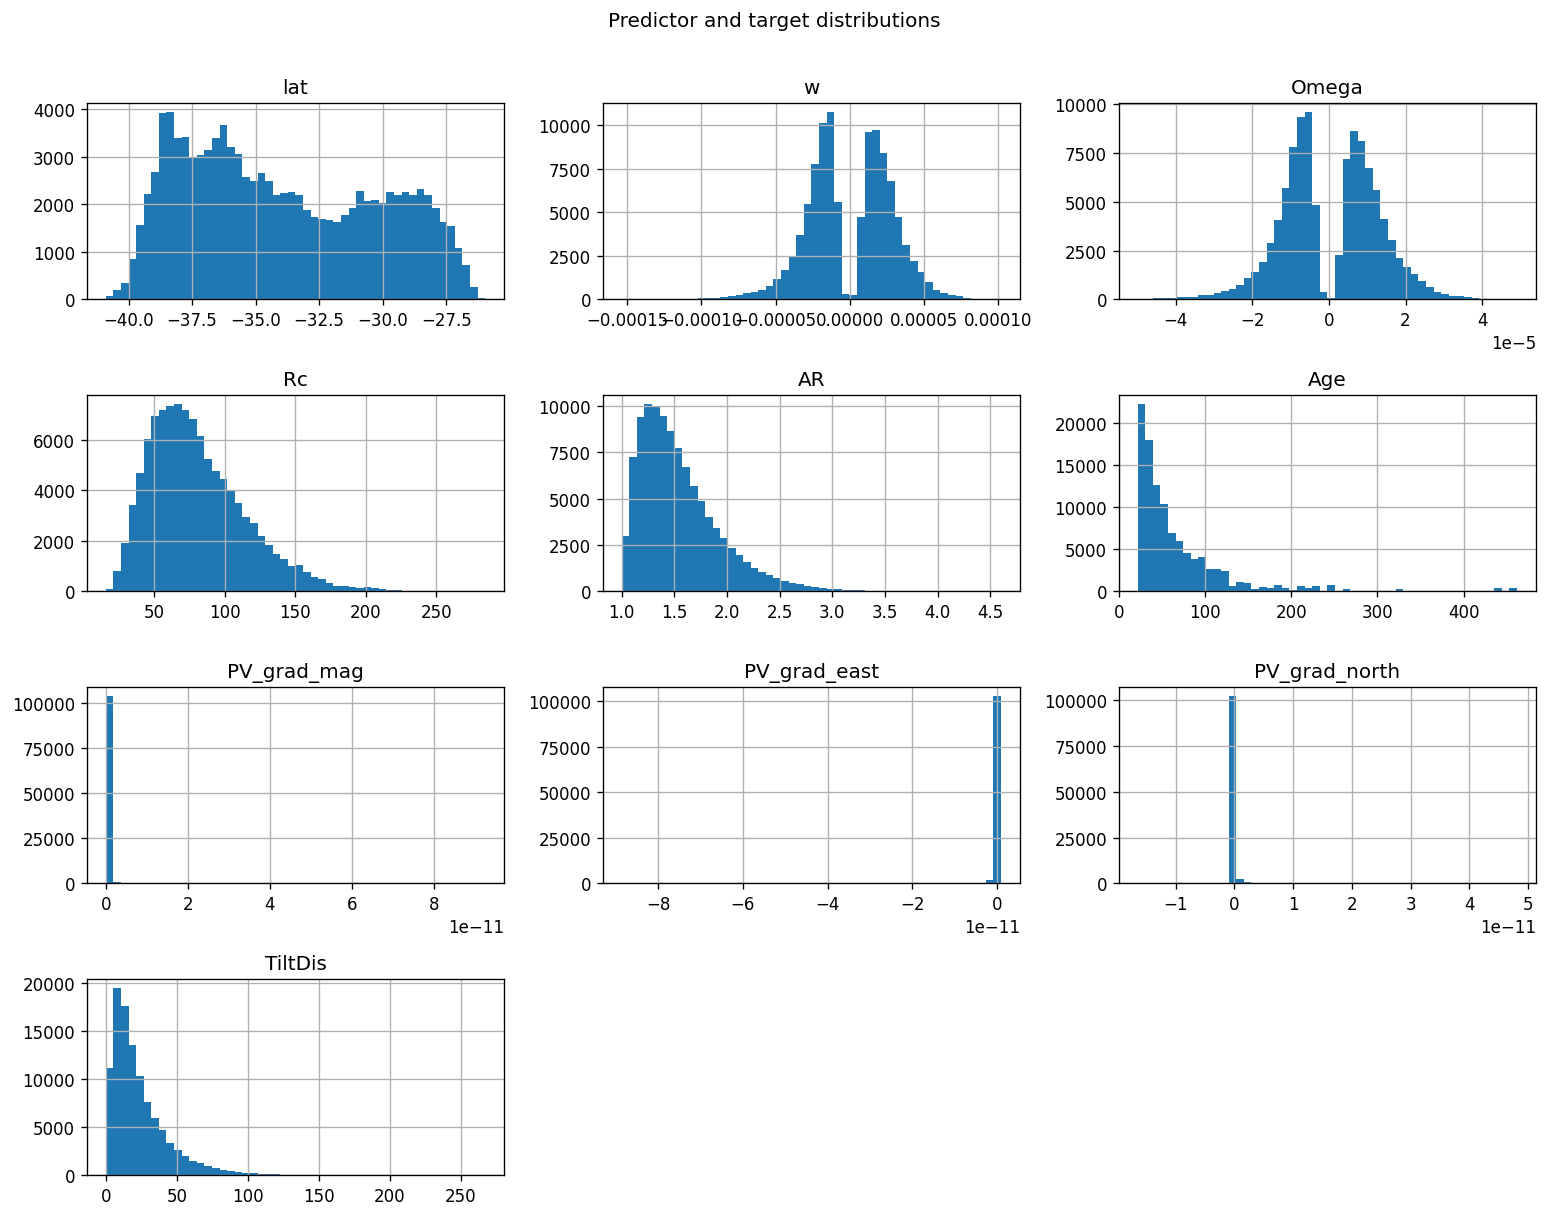

In [5]:
model_df[ml.NUMERIC_FEATURES + ["TiltDis"]].hist(bins=50, figsize=(13, 10))
plt.suptitle("Predictor and target distributions", y=1.01)
plt.tight_layout()

### Observed PV-gradient relationships

These panels inspect the two relationships motivating inclusion of the complete PV-gradient vector: gradient magnitude against tilt magnitude, and the circular difference between gradient and tilt direction. They are descriptive only; grouped validation below determines whether the relationships generalise to unseen eddies.

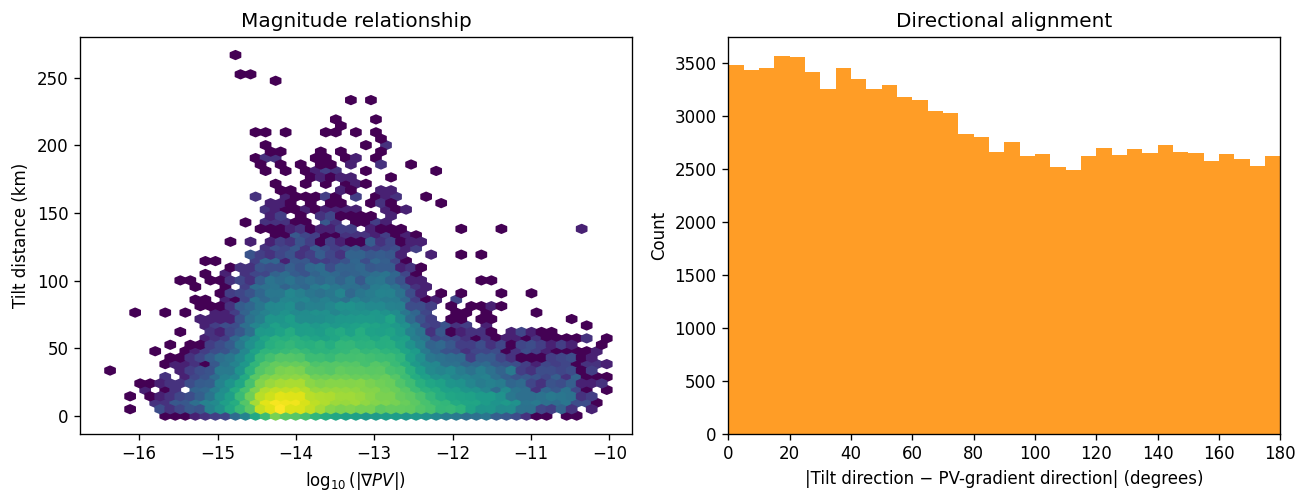

In [6]:
valid_pv = df_eddies[["PV_grad_mag", "PV_grad_theta", "TiltDis", "TiltDir"]].dropna()
valid_pv = valid_pv[valid_pv["PV_grad_mag"] > 0]
pv_tilt_angle = ml.angular_error_deg(valid_pv["TiltDir"], valid_pv["PV_grad_theta"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].hexbin(
    np.log10(valid_pv["PV_grad_mag"]),
    valid_pv["TiltDis"],
    gridsize=50, mincnt=1, bins="log", cmap="viridis",
)
axes[0].set(xlabel=r"$\log_{10}(|\nabla PV|)$", ylabel="Tilt distance (km)")
axes[0].set_title("Magnitude relationship")
axes[1].hist(pv_tilt_angle, bins=np.arange(0, 185, 5), color="darkorange", alpha=0.85)
axes[1].set(xlabel="|Tilt direction − PV-gradient direction| (degrees)", ylabel="Count", xlim=(0, 180))
axes[1].set_title("Directional alignment")
plt.tight_layout()

## 3. Hold out complete eddies

A random row split would leak adjacent days from the same eddy into training and testing. `GroupShuffleSplit` instead holds out 20% of eddy identities. The test set is untouched during fitting and is used for the final feasibility assessment.

In [7]:
split = ml.grouped_train_test_split(
    model_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

assert set(split.groups_train).isdisjoint(set(split.groups_test))
pd.Series({
    "training rows": len(split.X_train),
    "test rows": len(split.X_test),
    "training eddies": split.groups_train.nunique(),
    "test eddies": split.groups_test.nunique(),
})

training rows      84985
test rows          20636
training eddies     2362
test eddies          591
dtype: int64

## 4. Fit baseline, linear, and nonlinear models

The predictors are exactly:

```python
['lat', 'w', 'Omega', 'Rc', 'AR', 'Age',
 'PV_grad_mag', 'PV_grad_east', 'PV_grad_north']
```

with `Cyc` treated as a categorical predictor. `PV_grad_east` and `PV_grad_north` are derived from `PV_grad_mag` and `PV_grad_theta`; the raw angle is deliberately not supplied because it is circular. `Rc` is used rather than `R`. Ridge regression tests approximately linear vector relationships; histogram gradient boosting captures nonlinearities and interactions. Both are compared with the training-set mean tilt vector.

In [8]:
models = ml.build_models(random_state=RANDOM_STATE)
fitted_models = ml.fit_models(models, split)
scores, predictions = ml.evaluate_models(fitted_models, split)
scores.round(3)

,vector_MAE_km,vector_RMSE_km,distance_MAE_km,distance_RMSE_km,east_R2,north_R2,median_angular_error_deg,within_30deg_fraction,within_45deg_fraction
model,,,,,,,,,
Gradient boosting,23.202,31.138,16.145,25.188,0.037,0.096,56.414,0.295,0.416
Ridge,23.383,31.325,17.281,26.741,0.025,0.086,61.894,0.263,0.384
Mean-vector baseline,24.166,32.280,21.260,30.220,-0.002,-0.000,84.142,0.172,0.261


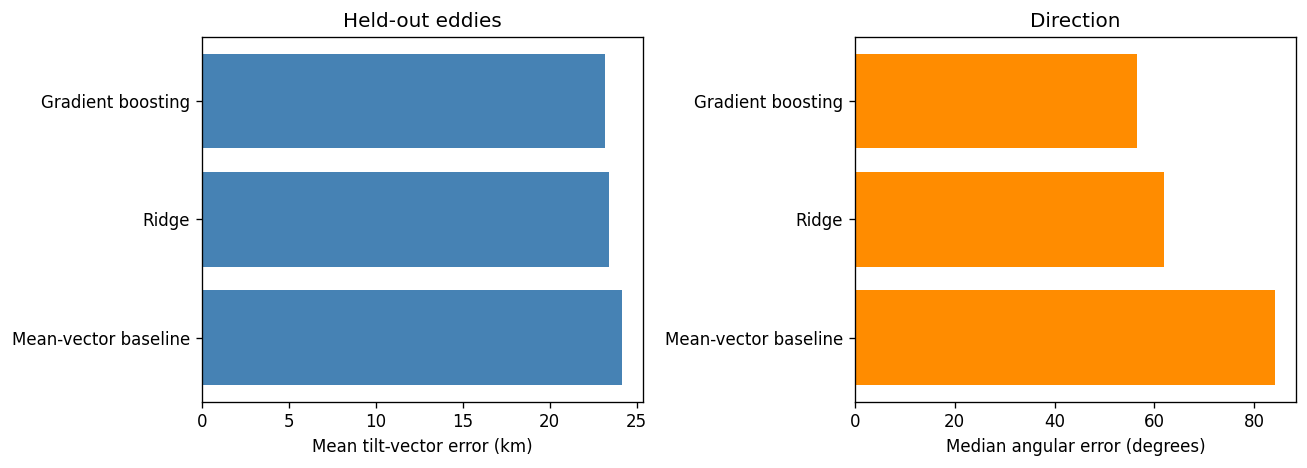

In [9]:
ml.plot_model_comparison(scores);

The primary metric is mean displacement-vector error because it jointly penalises distance and direction. Distance MAE measures magnitude skill. Angular error is reported separately, but should not dominate interpretation when observed tilt is close to zero and its direction is physically unstable. A useful model must improve materially on the mean-vector baseline on unseen eddies.

## 5. Diagnose the best predictive model

Best candidate on held-out eddies: Gradient boosting


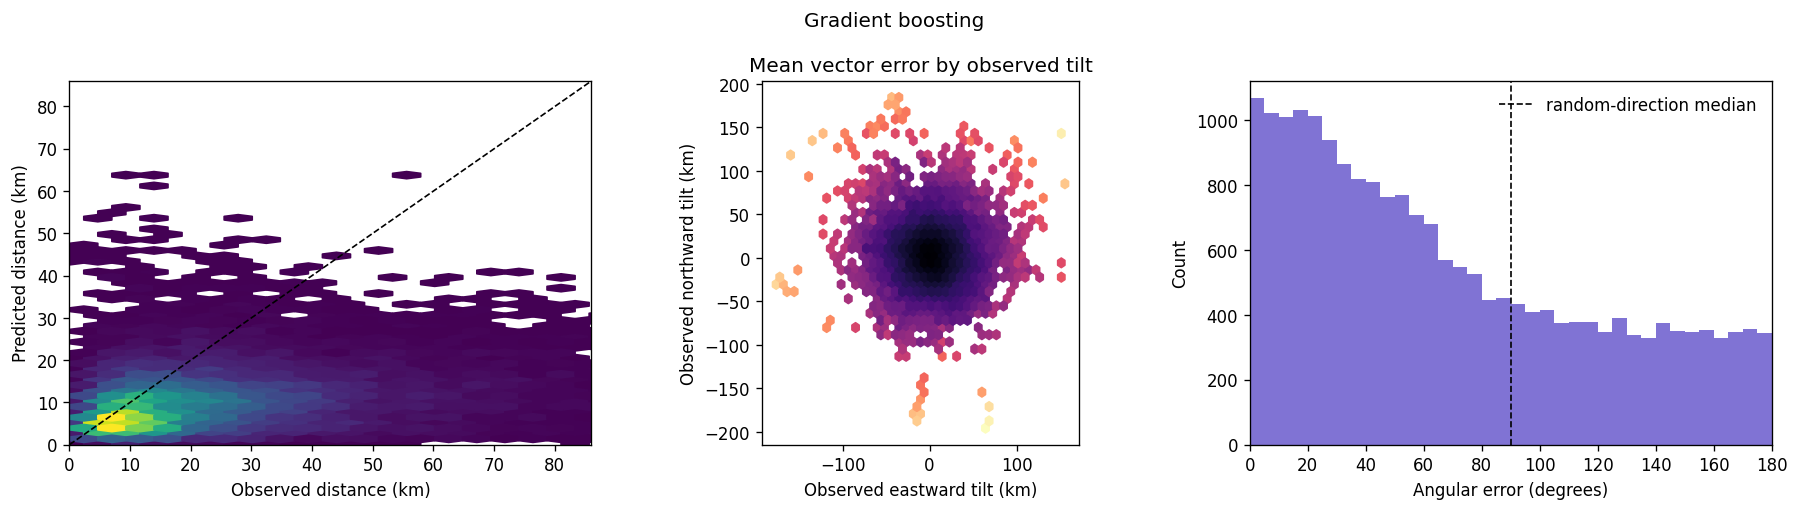

In [10]:
candidate_scores = scores.drop(index="Mean-vector baseline", errors="ignore")
best_name = candidate_scores["vector_MAE_km"].idxmin()
best_prediction = predictions[best_name]
print(f"Best candidate on held-out eddies: {best_name}")
ml.plot_prediction_diagnostics(best_prediction, title=best_name);

Direction is ill-defined for very small displacement. The next table repeats circular metrics after imposing progressively larger observed-tilt thresholds.

In [11]:
ml.direction_performance_by_tilt(best_prediction, thresholds=(0, 5, 10, 20)).round(3)

,rows,median_angular_error_deg,within_30deg_fraction,within_45deg_fraction
minimum_tilt_km,,,,
0,20636,56.414,0.295,0.416
5,18867,54.955,0.301,0.424
10,15361,53.588,0.307,0.434
20,9265,51.420,0.320,0.454


Performance is also separated by polarity. A large AE/CE contrast may justify fitting separate models later, but the first experiment keeps all data together and includes `Cyc` categorically.

In [12]:
ml.performance_by_group(
    best_prediction,
    model_df.loc[split.test_index],
    group_column="Cyc",
).round(3)

,rows,vector_MAE_km,distance_MAE_km,median_angular_error_deg,within_30deg_fraction
Cyc,,,,,
AE,11163,25.243,17.385,57.860,0.286
CE,9473,20.797,14.684,54.653,0.305


## 6. Grouped cross-validation

The single held-out split gives a clear final test. Five-fold grouped cross-validation measures sensitivity to which eddies are held out. This cell can take several minutes because both models are refitted five times.

In [13]:
cv_results = ml.grouped_cross_validation(models, model_df, n_splits=5)
cv_summary = cv_results.groupby("model").agg(
    vector_MAE_mean=("vector_MAE_km", "mean"),
    vector_MAE_std=("vector_MAE_km", "std"),
    distance_MAE_mean=("distance_MAE_km", "mean"),
    angular_error_median=("median_angular_error_deg", "median"),
    within_30deg_mean=("within_30deg_fraction", "mean"),
)
cv_summary.round(3)

,vector_MAE_mean,vector_MAE_std,distance_MAE_mean,angular_error_median,within_30deg_mean
model,,,,,
Gradient boosting,23.031,0.705,15.892,56.206,0.292
Ridge,23.062,0.714,17.035,61.201,0.271


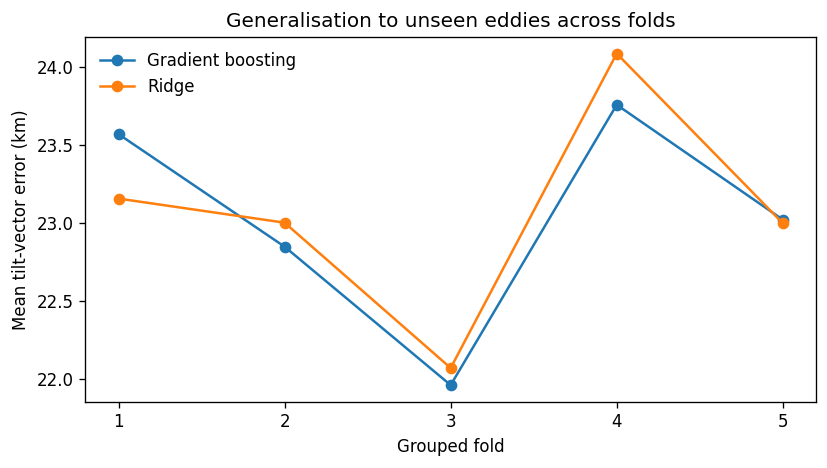

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, part in cv_results.groupby("model"):
    ax.plot(part["fold"], part["vector_MAE_km"], marker="o", label=name)
ax.set(xlabel="Grouped fold", ylabel="Mean tilt-vector error (km)", xticks=range(1, 6))
ax.set_title("Generalisation to unseen eddies across folds")
ax.legend(frameon=False)
plt.tight_layout()

## 7. Held-out permutation importance

Each raw predictor is shuffled in the untouched test set. Importance is the resulting increase in mean vector error. This measures predictive reliance, not causality; correlated predictors can share or mask importance.

,feature,importance_mean,importance_std
9,Cyc,2.8397,0.0584
0,lat,1.1287,0.0345
7,PV_grad_east,0.3866,0.0204
1,w,0.3093,0.0276
5,Age,0.2786,0.0281
8,PV_grad_north,0.2672,0.0117
3,Rc,0.2640,0.0147
2,Omega,0.2290,0.0135
6,PV_grad_mag,0.1858,0.0122
4,AR,0.1203,0.0085


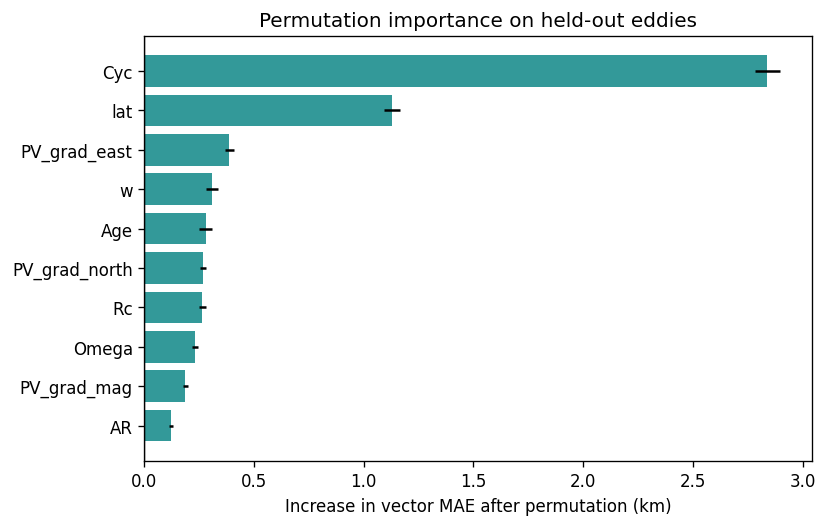

In [15]:
importance = ml.raw_feature_permutation_importance(
    fitted_models[best_name],
    split.X_test,
    split.y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
)
display(importance.round(4))
ml.plot_permutation_importance(importance);

## 8. Interpretation checklist and next experiments

Treat surface-to-tilt prediction as feasible only when the nonlinear and/or linear model improves consistently over the baseline in both the held-out split and grouped folds. Report vector error first, followed by distance and thresholded angular metrics.

Before drawing a physical conclusion:

1. verify that tilt uses a common reference depth;
2. quantify how missing tilt depends on polarity and surface predictors;
3. inspect whether performance differs materially between AE and CE;
4. repeat with entire years held out to test temporal transfer;
5. compare this surface-only feature set with a context model containing season, longitude, region, or bathymetry;
6. do not interpret permutation importance as causal evidence.

A useful scientific result can be either positive or negative: strong out-of-eddy skill indicates predictable surface information, while weak skill after leakage-safe validation shows that these surface signatures alone do not constrain instantaneous subsurface tilt sufficiently.